In [1]:
import warnings

import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import seaborn as sn

warnings.simplefilter("ignore")
plt.style.use("ggplot")

# TEOTIL3 for Lillestrøm kommune
# Notebook 04: Estimate annual loads

## 1. Sites of interest

In [2]:
# Read site data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
stn_df = pd.read_excel(xl_path, sheet_name="chem_stns")
stn_df

,catchment,station_id,station_name,regine,wb_id,wb_name,lon,lat,comment
0,Sagelva,002-46599,Sagelva ved Skjetten bro (F3),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,11.01695,59.95850,Downstream
1,Sagelva,002-63540,Fjellhammarelva (F10),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,10.99617,59.94419,Slightly upstream
2,Nitelva,002-30586,Rud Nitelva (N8),002.CB0,002-3891-R,Nedre Nitelva,11.05700,59.94553,Downstream
3,Nitelva,002-30578,Kjellerholen Nitelva (N6),002.CC0,002-1638-R,Nitelva Slattum-Kjeller,11.00850,59.97925,Slightly upstream
4,Leira,002-29659,Leira ved Borgen bru (L5),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.10032,59.95036,Downstream
5,Leira,002-30584,Leira ved Leirsund (L8),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.08849,59.99755,Slightly upstream
6,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,002.D2Z,002-3659-R,Rømua,11.22099,60.02163,Downstream
7,Jeksla,002-30593,"Jeksla ved Haugli, J14",002.CAA0,002-599-R,Jeksla,11.10637,60.00199,Downstream. Small part of regine
8,Åa,002-60929,Fossåa ved Sylta (ÅA1),002.D3Z,002-3685-R,Fossåa,11.30018,59.99209,Downstream
9,Åa,002-60963,Sloråa ved Bruvollen (ÅA3),002.D3Z,002-3687-R,Sloråa,11.34807,59.98512,Upstream. North branch


## 2. Water chemistry data

Use the cleaned and filtered water chemistry data from Notebook 02.

In [3]:
# Chem from Vannmiljø
xl_path = r"../data/cleaned_concs_stations.xlsx"
wc_df = pd.read_excel(xl_path, sheet_name="cleaned_chem")
wc_df.columns = [col.replace("µ", "u") for col in wc_df.columns]
wc_df.head()

,station_code,station_name,sample_date,year,SS_mg/l,TOC_mg/l,TOTN_ug/l,TOTP_ug/l
0,002-28960,Rømua ved Lørenfallet - RØM1,1990-04-30,1990,22.0,7.7,1790.0,54.0
1,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-14,1990,6.8,5.9,1080.0,34.0
2,002-28960,Rømua ved Lørenfallet - RØM1,1990-05-28,1990,14.0,4.2,1430.0,34.0
3,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-11,1990,10.0,4.5,1100.0,40.0
4,002-28960,Rømua ved Lørenfallet - RØM1,1990-06-25,1990,24.0,4.7,2260.0,65.0


## 3. Flow data

Use modelled data from the GTS API. For Sagelva, we also have measured data from the same location as the water chemistry sampling, so we can check to assess the effect of using modelled discharge (at least for this single location) - see Section 6.

The GTS data in this area seems to be biased low, with relative biases of -0.159123 and -0.178468 for stations `2.1185.0` and `2.279.0`, respectively. To make the mean of the GTS simulation better match the mean of the observed flows, a simple bias factor can be applied:

$$f = \frac{Obs_{avg}}{Mod_{avg}} = \frac{1}{1 + bias}$$

This gives bias factors of 1.19 and 1.22, respectively i.e. the GTS API underestimates flows by about 20 %. I will therefore scale the flows by a factor of 1.2. This will solve the mean bias issue, but will not resolve the low variability in the GTS simulations.

In [4]:
# Bias correction to apply to GTS API data
gts_bias_fac = 1.2

In [5]:
# Flows from NVE
xl_path = r"../data/nve_data.xlsx"
gts_df = pd.read_excel(xl_path, sheet_name="gts-api")
nve_df = pd.read_excel(xl_path, sheet_name="hyd-api")
gts_df.head()

,date,002-101949,002-106796,002-106815,002-106818,002-109603,002-109604,002-109608,002-111393,002-112453,...,002-79092,002-79097,002-79557,002-80573,002-81594,002-81595,002-91322,002-94483,002-98385,002-98386
0,1980-01-01,0.998913,0.129389,0.234766,0.233588,0.588398,0.538709,0.324984,2.258290,0.580173,...,2.901668,1.046488,1.749078,3.046249,3.087813,5.773402,0.067665,0.069442,1.580484,1.629586
1,1980-01-02,0.920197,0.126014,0.227687,0.226545,0.562034,0.513900,0.319262,2.149286,0.553964,...,2.723901,0.967863,1.660796,2.852126,2.905301,5.484510,0.064337,0.067932,1.502468,1.553539
2,1980-01-03,0.845916,0.119263,0.220609,0.219502,0.546455,0.498542,0.315829,2.068717,0.538477,...,2.544283,0.891453,1.609298,2.676668,2.720926,5.213396,0.062118,0.063403,1.441939,1.493788
3,1980-01-04,0.788265,0.118138,0.218249,0.217155,0.540463,0.492635,0.308963,2.004736,0.532520,...,2.412810,0.833868,1.554123,2.538541,2.573799,5.004504,0.061009,0.063403,1.393516,1.436752
4,1980-01-05,0.751679,0.115888,0.217070,0.215981,0.530876,0.484365,0.305531,1.990518,0.522990,...,2.320223,0.797324,1.541248,2.435880,2.465781,4.880058,0.059900,0.063403,1.366614,1.412308


## 4. Estimate annual loads

Using the OSPAR method (the same method used for Elveovervåkingsprogrammet).

In [6]:
val_cols = [
    "TOTN_ug/l",
    "TOTP_ug/l",
    "SS_mg/l",
    "TOC_mg/l",
]
df_list = []
for stn_id, stn_wc_df in wc_df.groupby("station_code"):
    # Prepare data
    stn_wc_df = stn_wc_df.set_index("sample_date")[val_cols].sort_index()
    q_df = gts_df.set_index("date")[[stn_id]] * gts_bias_fac
    q_df.columns = ["flow_m3/s"]

    # Calculate loads
    lds_df = (
        nivapy.stats.estimate_fluxes(
            q_df,
            stn_wc_df,
            base_freq="D",
            agg_freq="YE",
            method="ospar_annual",
            st_date=None,
            end_date=None,
            plot_fold=None,
        )
        .dropna(how="all")
        .reset_index()
    )

    # Convert to tonnes
    cols = [col for col in lds_df.columns if col.endswith("_kg")]
    lds_df[cols] = lds_df[cols] / 1000
    cols = [col.replace("kg", "tonn") for col in lds_df.columns]
    lds_df.columns = cols
    lds_df = lds_df.reset_index()
    lds_df["station_code"] = stn_id
    lds_df = lds_df[
        ["station_code", "year"]
        + [col for col in lds_df.columns if col.endswith("_tonn")]
    ]
    df_list.append(lds_df)
lds_df = pd.concat(df_list, axis="rows")
lds_df.head()

,station_code,year,TOTN_tonn,TOTP_tonn,SS_tonn,TOC_tonn
0,002-28960,1990,115.560708,3.761664,1350.251474,449.488781
1,002-28960,1991,226.497865,9.614614,6994.710454,624.249353
2,002-28960,1992,204.904427,6.469359,3619.275923,551.968693
3,002-28960,1998,278.580661,10.117601,3775.236635,794.754813
4,002-28960,1999,280.977050,29.369158,23878.076506,NaN


## 5. Tests for trends

Using Mann-Kendall and Sen's slope.

,catchment,station_id,station_name,comment,par,mk_trend,mk_pval,sslp,sslp_ub,sslp_lb
0,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,TOTN_tonn,no trend,0.397587,2.323377,6.289783,-1.888829
1,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,TOTP_tonn,no trend,0.158570,0.399670,0.762681,-0.140602
2,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,SS_tonn,no trend,0.101948,284.551045,721.415158,-67.626563
3,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,Downstream,TOC_tonn,increasing,0.037198,19.587082,39.202640,1.590324
4,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,TOTN_tonn,no trend,0.144487,6.933539,14.121479,-2.403095
5,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,TOTP_tonn,no trend,0.757640,-0.087953,1.826417,-2.035080
6,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,SS_tonn,no trend,0.673262,-725.699456,1726.591555,-2633.272788
7,Leira,002-29659,Leira ved Borgen bru (L5),Downstream,TOC_tonn,increasing,0.014326,67.585896,175.611758,12.733750
8,Nitelva,002-30578,Kjellerholen Nitelva (N6),Slightly upstream,TOTN_tonn,increasing,0.003160,3.470934,4.593435,1.944762
9,Nitelva,002-30578,Kjellerholen Nitelva (N6),Slightly upstream,TOTP_tonn,no trend,0.333358,0.074073,0.295052,-0.104539


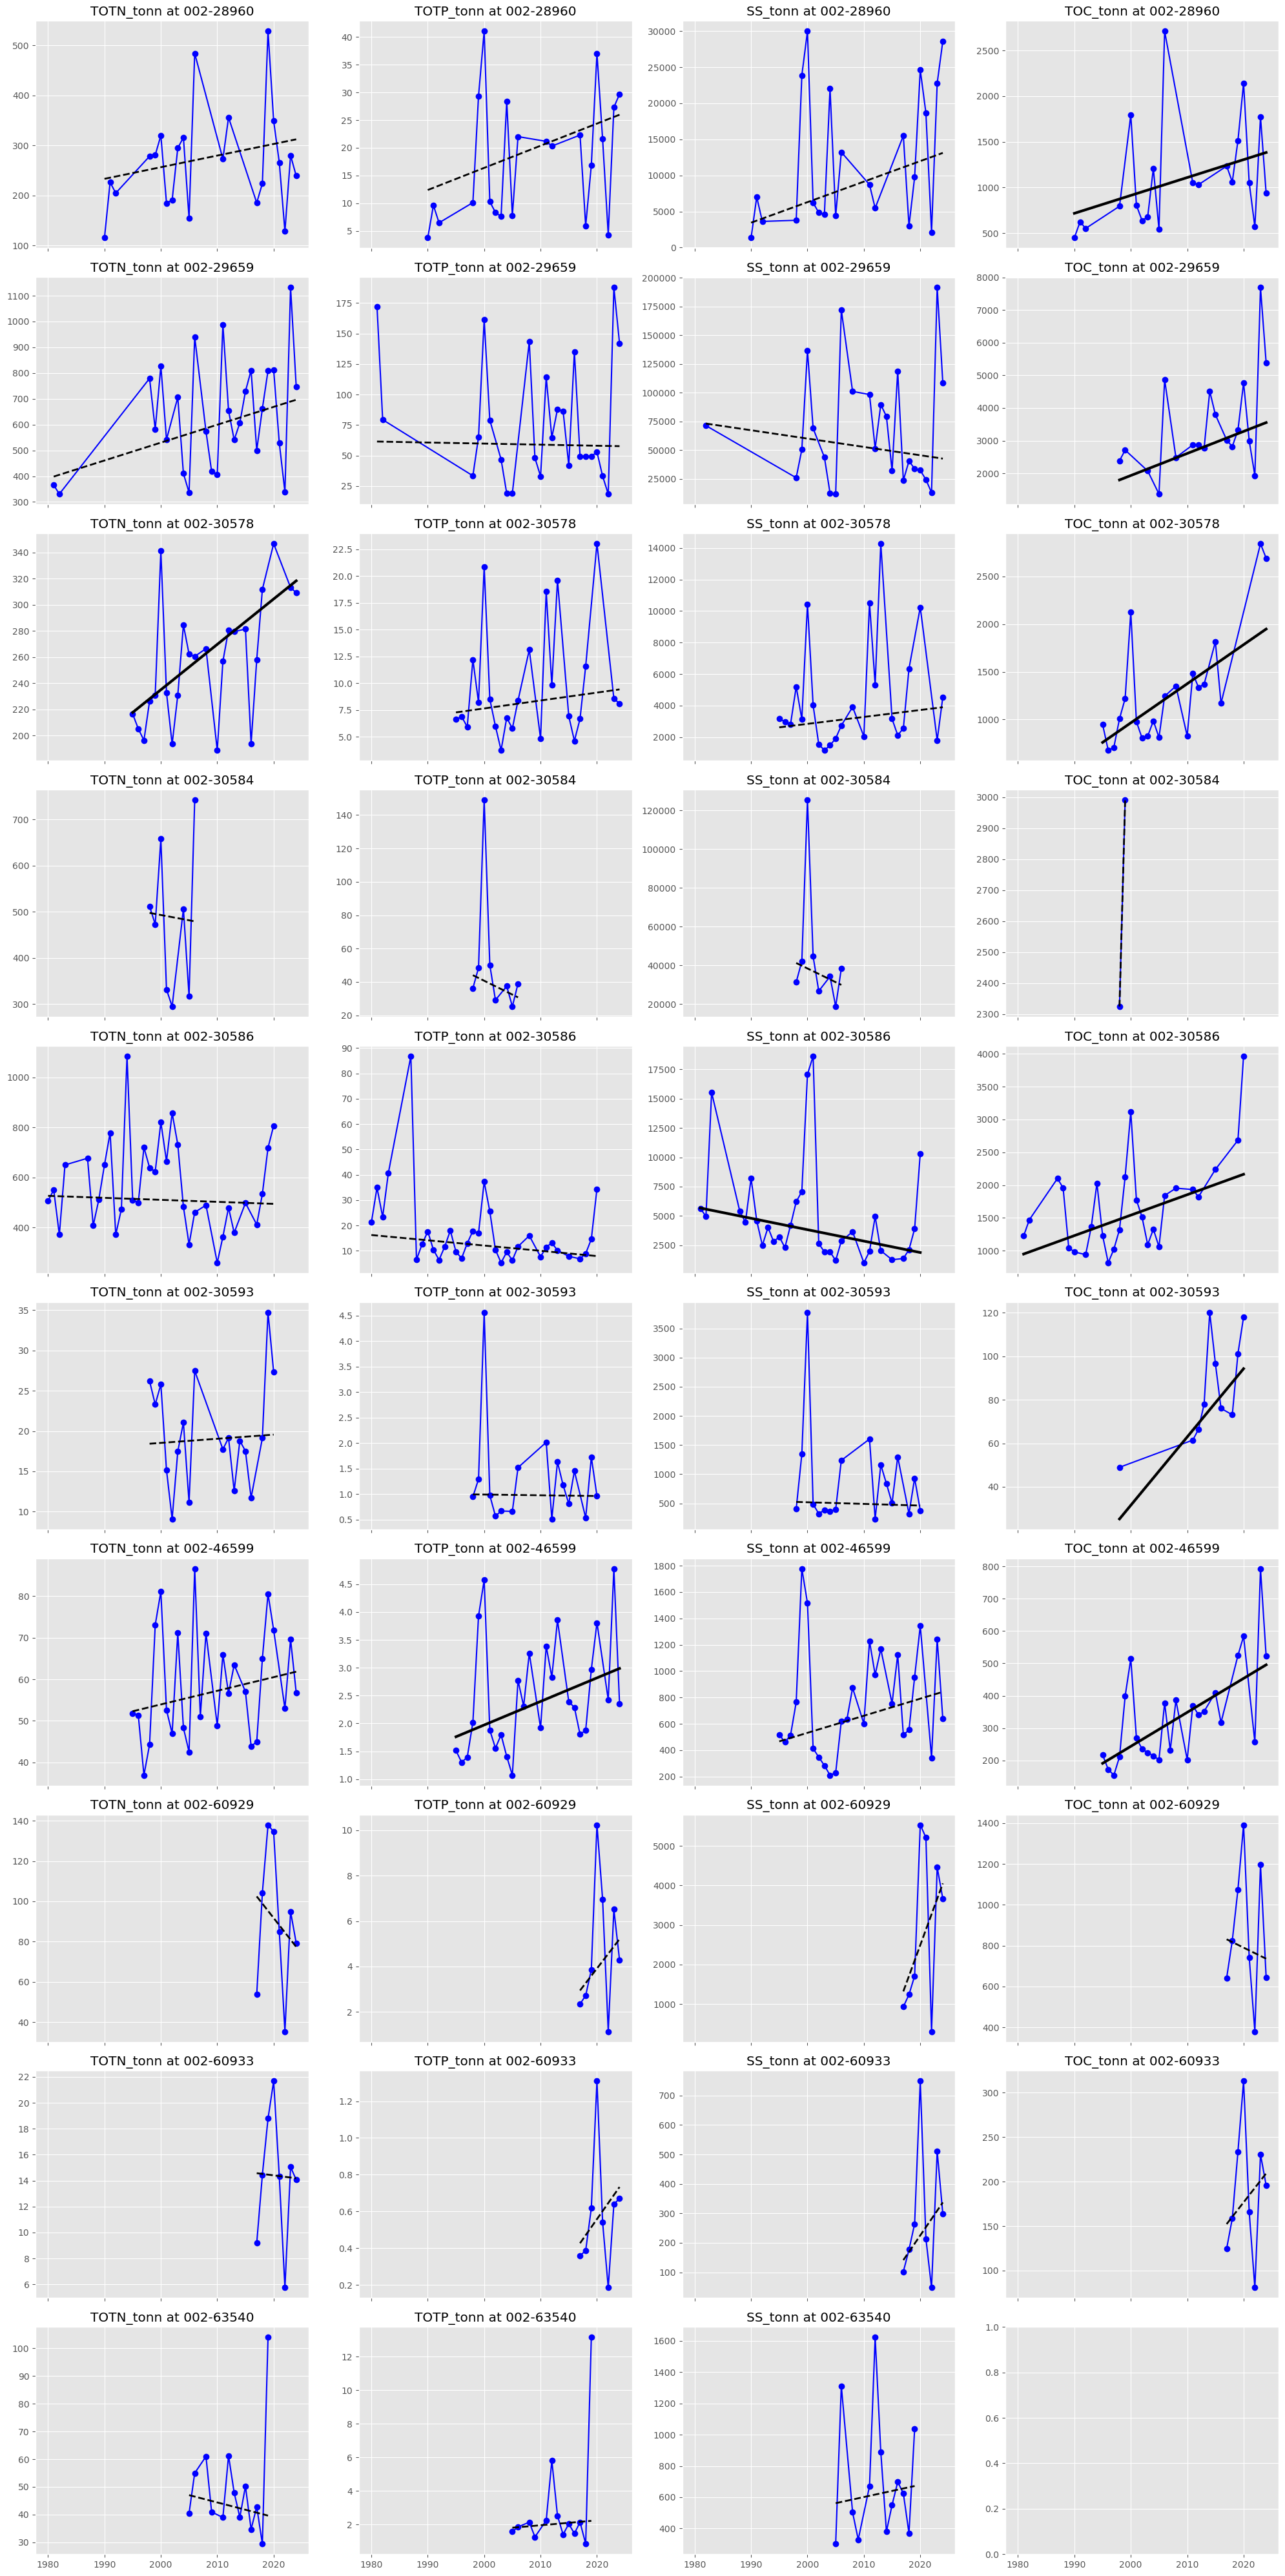

In [7]:
val_cols = ["TOTN_tonn", "TOTP_tonn", "SS_tonn", "TOC_tonn"]
fig, axes = plt.subplots(
    nrows=len(lds_df["station_code"].unique()),
    ncols=4,
    figsize=(20, 40),
    sharex=True,
    sharey=False,
)

res_dict = {
    "station_id": [],
    "par": [],
    "mk_trend": [],
    "mk_pval": [],
    "sslp": [],
    "sslp_ub": [],
    "sslp_lb": [],
}
for row_idx, (stn_id, stn_lds_df) in enumerate(lds_df.groupby("station_code")):
    stn_lds_df = stn_lds_df.sort_values("year")
    for col_idx, par in enumerate(val_cols):
        stn_par_df = stn_lds_df[["year", par]].dropna(subset=par)

        if len(stn_par_df) > 1:
            # Test for trends
            mk_df = nivapy.stats.mk_test(stn_par_df, par, alpha=0.05)
            res_df, sen_df = nivapy.stats.sens_slope(
                stn_par_df, par, index_col="year", alpha=0.05
            )

            # Extract results
            trend = mk_df.loc["trend", "value"]
            pval = mk_df.loc["p", "value"]
            sslp = res_df.loc["sslp"]["value"]
            icpt = res_df.loc["icpt"]["value"]
            lb = res_df.loc["lb"]["value"]
            ub = res_df.loc["ub"]["value"]

            # Add to results
            res_dict["station_id"].append(stn_id)
            res_dict["par"].append(par)
            res_dict["mk_trend"].append(trend)
            res_dict["mk_pval"].append(pval)
            res_dict["sslp"].append(sslp)
            res_dict["sslp_ub"].append(ub)
            res_dict["sslp_lb"].append(lb)

            # Plot
            axes[row_idx, col_idx].plot(stn_par_df["year"], stn_par_df[par], "bo-")
            if trend != "no trend":
                axes[row_idx, col_idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "k-",
                    lw=3,
                )
            else:
                axes[row_idx, col_idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "k--",
                    lw=2,
                )
            axes[row_idx, col_idx].set_title(f"{par} at {stn_id}")

    plt.tight_layout()
png_path = r"../plots/loads/all_stations_ann_loads.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")

# Merge results
stat_df = pd.DataFrame(res_dict)
stat_df = pd.merge(
    stn_df[["catchment", "station_id", "station_name", "comment"]],
    stat_df,
    how="right",
    on="station_id",
)

stat_df

In [8]:
# Save
xl_path = r"../data/annual_loads_stations.xlsx"
with pd.ExcelWriter(xl_path) as writer:
    lds_df.to_excel(writer, sheet_name="annual_loads", index=False)
    stat_df.to_excel(writer, sheet_name="load_trends", index=False)

## 6. Check effect of using NVE's modelled discharge data

Compare load estimates for Sagelva using (i) measured discharge from the NVE station at the same location as the chemistry sampling site, and (ii) simulated water discharge via the GTS API.

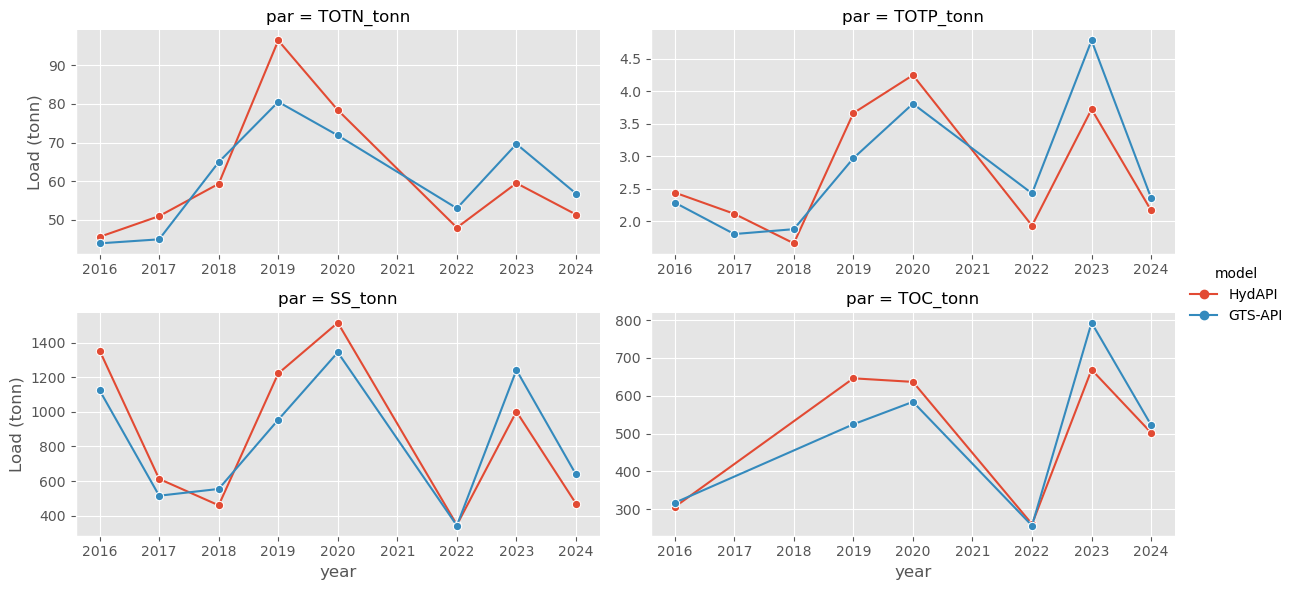

In [9]:
wc_id = "002-46599"
nve_id = "2.1185.0"

sag_wc_df = wc_df.query("station_code == @wc_id").set_index("sample_date")[
    ["TOTN_ug/l", "TOTP_ug/l", "SS_mg/l", "TOC_mg/l"]
]
q_df = nve_df.query("station_id == @nve_id").set_index("date")[
    ["nve_obs_discharge_m3ps"]
]
q_df.columns = ["flow_m3/s"]
sag_lds_df = (
    nivapy.stats.estimate_fluxes(
        q_df,
        sag_wc_df,
        base_freq="D",
        agg_freq="YE",
        method="ospar_annual",
        st_date=None,
        end_date=None,
        plot_fold=None,
    )
    .dropna(how="all")
    .reset_index()
)

# Convert to tonnes
cols = [col for col in sag_lds_df.columns if col.endswith("_kg")]
sag_lds_df[cols] = sag_lds_df[cols] / 1000
cols = [col.replace("kg", "tonn") for col in sag_lds_df.columns]
sag_lds_df.columns = cols

sag_lds_df2 = lds_df.query("(station_code == @wc_id) and (year >= 2016)")[
    sag_lds_df.columns
].copy()
sag_lds_df["model"] = "HydAPI"
sag_lds_df2["model"] = "GTS-API"

sag_lds_df = pd.concat([sag_lds_df, sag_lds_df2], axis="rows").melt(
    id_vars=["model", "year"], var_name="par", value_name="Load (tonn)"
)

sn.relplot(
    data=sag_lds_df,
    x="year",
    y="Load (tonn)",
    hue="model",
    col="par",
    col_wrap=2,
    kind="line",
    marker="o",
    facet_kws={"sharex": False, "sharey": False},
    height=3,
    aspect=2,
)

Without bias correction (i.e. with `gts_bias_fac = 1` in the code above), annual loads estimated using water discharge from the GTS API are slightly lower than loads using "real" monitoring data. This is consistent with the assessment in Notebook 02, which showed that simulated flows from the GTS API are biased-low by around 20 %. Using a bias correction factor of 1.2, as in the code above, resolves this and produces reasonable estimates of annual loads for Sagelva.